<h1 align="center"> Car Damage Classification using Deep Learning <h1/>

## 📌 Objective

This project builds a deep learning image classification system to classify different types of car damage using CNNs and transfer learning models such as EfficientNet and ResNet.

## 🚀 Key Highlights

- Build baseline CNN models
- Reduce overfitting using regularization
- Apply transfer learning
- Compare model performance
- Deploy the final model using Streamlit and FastAPI

### Import Libraries

In [1]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time
import torchvision.models as models
from matplotlib import pyplot as plt
from torch.utils.data import random_split

In [2]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Data Load and Transformation

The dataset size is relatively small, and deep learning models generally require large amounts of data to learn robust features. With limited data, models are more likely to overfit and perform poorly on unseen images.

To improve generalization, data augmentation techniques such as horizontal flipping, rotation, cropping, zooming, and brightness adjustment are applied. These transformations generate different variations of the same image during training without modifying the original image files.


In [3]:
image_transforms=transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2,contrast=0.2),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
])

The normalization values correspond to the channel-wise mean and standard deviation of the ImageNet dataset. Since pretrained models such as ResNet, VGG, and EfficientNet were originally trained on ImageNet, using the same normalization ensures that input images follow a similar distribution during transfer learning.

Images are resized to `224 × 224` because most ImageNet pretrained CNN architectures expect this input size.

In [4]:
dataset_path = "./dataset"

dataset=datasets.ImageFolder(root=dataset_path,transform=image_transforms)
len(dataset)

2300

In [5]:
class_names=dataset.classes
class_names

['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']

In [6]:
num_classes=len(dataset.classes)
num_classes

6

In [7]:
train_size=int(0.75*len(dataset))
val_size=len(dataset)-train_size

train_size,val_size

(1725, 575)

In [8]:
train_dataset,val_dataset = random_split(dataset,[train_size,val_size])

#### Dataset Summary

- Total Classes: 6
- Total Images: 2300
- Training Split: 75%
- Validation Split: 25%

The dataset contains images of damaged and undamaged cars captured under different conditions.

In [9]:
train_loader = DataLoader(train_dataset, batch_size=32,  shuffle=True)
val_loader  = DataLoader(val_dataset,   batch_size=32,  shuffle=False)

In [10]:
for images,labels in train_loader:
    print(images.shape)
    print(labels.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


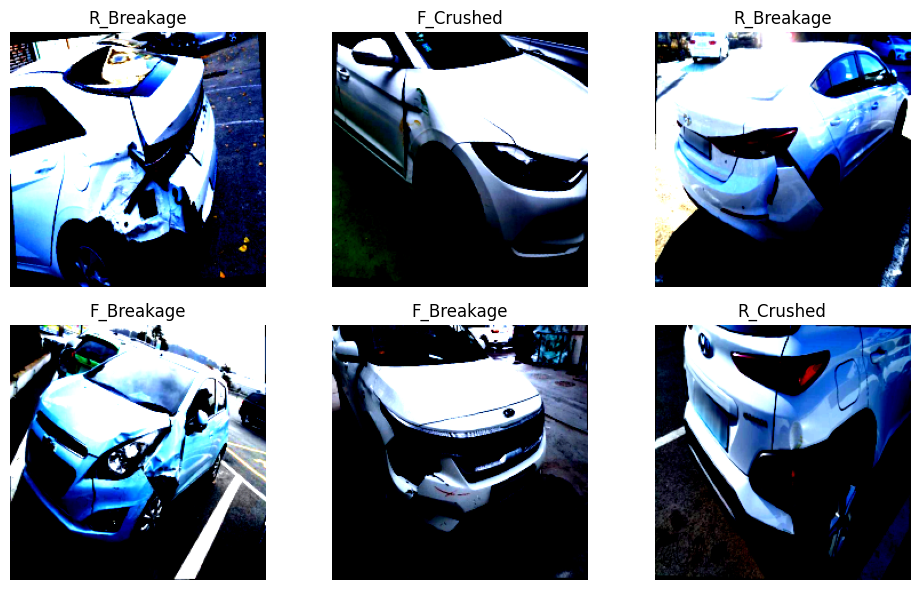

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(10,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].permute(1,2,0))
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Model1: Baseline CNN Model

In [15]:
class CarClassifierCNN(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network= nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1), #output (16,224,224)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),# (16,112,112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1), #output (32,112,112)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1), #output (64,56,56)
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), # output (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x=self.network(x)
        return x

In [16]:
#Instantiate the model, loss function and optimizer

model=CarClassifierCNN(num_classes=num_classes).to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss()

In [17]:
def train_model(model,criterion,optimizer,epochs=5):
    start=time.time()
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    
    for epoch in range(epochs):
        model.train()
        running_loss=0.0
        for batch_num, (images,labels) in enumerate(train_loader):

            images,labels = images.to(device),labels.to(device)

            #zeroing gradients
            optimizer.zero_grad()

            #forward pass
            outputs=model(images)
            loss=criterion(outputs,labels)

            #backward pass
            loss.backward()
            optimizer.step()

            running_loss+=loss.item()*images.size(0)

        epoch_loss=running_loss/len(train_loader.dataset)     # Average loss per image for the entire epoch
        train_losses.append(epoch_loss)
        
        
        # Validation
        model.eval()
        val_loss = 0.0
        correct=0
        total=0
        all_labels=[]
        all_predictions=[]

        with torch.no_grad():
            for images,labels in val_loader:
                images,labels = images.to(device),labels.to(device)
                output=model(images)
                
                loss=criterion(output,labels)
                val_loss+=loss.item()*images.size(0)
                
                _,predictions=torch.max(output.data,1)
                correct+=(predictions==labels).sum().item()
                total+=labels.size(0)
                all_labels.extend(labels.cpu().numpy())
                all_predictions.extend(predictions.cpu().numpy())
            
            epoch_val_loss = val_loss / len(val_loader.dataset)
            accuracy=(100*correct)/total
            val_losses.append(epoch_val_loss)
            val_accuracies.append(accuracy)
            
        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {epoch_loss:.2f} | "
            f"Val Loss: {epoch_val_loss:.2f} | "
            f"Val Accuracy: {accuracy:.2f}%"
            )
        
    end=time.time()
    print(f"Execution Time {end-start} seconds")
    return all_labels,all_predictions, train_losses,val_losses, val_accuracies

In [ ]:
def plot_metrics(train_losses, val_losses, val_accuracies):

    # Loss Plot
    plt.figure(figsize=(8,5))

    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title("Training vs Validation Loss")

    plt.legend()

    plt.show()

    # Accuracy Plot
    plt.figure(figsize=(8,5))

    plt.plot(val_accuracies)

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title("Validation Accuracy")

    plt.show()

In [18]:
labels,predictions,train_losses,val_losses, val_accuracies=train_model(model,criterion,optimizer,epochs=5)

Epoch [1/5] Train Loss: 1.81 | Val Loss: 1.53 | Val Accuracy: 36.70%
Epoch [2/5] Train Loss: 1.37 | Val Loss: 1.33 | Val Accuracy: 44.52%
Epoch [3/5] Train Loss: 1.24 | Val Loss: 1.20 | Val Accuracy: 46.78%
Epoch [4/5] Train Loss: 1.06 | Val Loss: 1.11 | Val Accuracy: 50.26%
Epoch [5/5] Train Loss: 0.95 | Val Loss: 1.01 | Val Accuracy: 53.22%
Execution Time 595.9416694641113 seconds


In [ ]:
plot_metrics(train_losses, val_losses, val_accuracies)

We can see from above the training loss is improving but accuracy isnt changing much. This means the model is overfitting. To resolve this we do regularisation techniques like dropout layers, batch normalisation etc.

## Model 2: CNN with Regularization

In [22]:
class CarClassifierCNNwithRegularistion(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.network= nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=16,kernel_size=3,stride=1,padding=1), #output (16,224,224)
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),# (16,112,112)
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,stride=1,padding=1), #output (32,112,112)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0),
            nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding=1), #output (64,56,56)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,stride=2,padding=0), # output (64,28,28)
            nn.Flatten(),
            nn.Linear(64*28*28,512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,num_classes)
        )

    def forward(self,x):
        x=self.network(x)
        return x

In [23]:
#Instantiate the model, loss function and optimizer

model=CarClassifierCNNwithRegularistion(num_classes=num_classes).to(device)
optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-4)
criterion=nn.CrossEntropyLoss()

In [24]:
labels,predictions,train_losses,val_losses, val_accuracies=train_model(model,criterion,optimizer,epochs=10)

Batch Number: 10, Epoch :1, Loss: 10.27
Batch Number: 20, Epoch :1, Loss: 6.58
Batch Number: 30, Epoch :1, Loss: 2.01
Batch Number: 40, Epoch :1, Loss: 1.44
Batch Number: 50, Epoch :1, Loss: 1.73
Epoch: [1/10], Avg Loss = 7.9665 
Validation Accuracy: 35.48%***
Batch Number: 10, Epoch :2, Loss: 1.52
Batch Number: 20, Epoch :2, Loss: 1.55
Batch Number: 30, Epoch :2, Loss: 1.20
Batch Number: 40, Epoch :2, Loss: 1.24
Batch Number: 50, Epoch :2, Loss: 1.81
Epoch: [2/10], Avg Loss = 1.5030 
Validation Accuracy: 41.57%***
Batch Number: 10, Epoch :3, Loss: 1.28
Batch Number: 20, Epoch :3, Loss: 1.67
Batch Number: 30, Epoch :3, Loss: 1.31
Batch Number: 40, Epoch :3, Loss: 1.76
Batch Number: 50, Epoch :3, Loss: 1.27
Epoch: [3/10], Avg Loss = 1.4368 
Validation Accuracy: 48.87%***
Batch Number: 10, Epoch :4, Loss: 1.17
Batch Number: 20, Epoch :4, Loss: 1.25
Batch Number: 30, Epoch :4, Loss: 1.23
Batch Number: 40, Epoch :4, Loss: 1.05
Batch Number: 50, Epoch :4, Loss: 1.35
Epoch: [4/10], Avg Loss 

In [ ]:
plot_metrics(train_losses, val_losses, val_accuracies)

Even after regularization, we can see that the accuracy hasnt improved much. So next option is transfer learning.

## Model 3 : Transfer learning with EfficientNet

In [25]:
class CarClassifierEfficientNet(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.model=models.efficientnet_b0(weights="DEFAULT")
        for param in self.model.parameters():
            param.requires_grad=False
        in_features=self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(  #to get last fully connected layer
            nn.Dropout(0.5),
            nn.Linear(in_features,num_classes)
        )

    def forward(self,x):
        x=self.model(x)
        return x

In [26]:
model = CarClassifierEfficientNet(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.001)

In [27]:
labels,predictions,train_losses,val_losses,val_accuracies=train_model(model,criterion,optimizer,epochs=10)

Batch Number: 10, Epoch :1, Loss: 1.81
Batch Number: 20, Epoch :1, Loss: 1.57
Batch Number: 30, Epoch :1, Loss: 1.40
Batch Number: 40, Epoch :1, Loss: 1.33
Batch Number: 50, Epoch :1, Loss: 1.48
Epoch: [1/10], Avg Loss = 1.4892 
Validation Accuracy: 60.17%***
Batch Number: 10, Epoch :2, Loss: 1.25
Batch Number: 20, Epoch :2, Loss: 1.10
Batch Number: 30, Epoch :2, Loss: 1.09
Batch Number: 40, Epoch :2, Loss: 1.14
Batch Number: 50, Epoch :2, Loss: 1.03
Epoch: [2/10], Avg Loss = 1.1410 
Validation Accuracy: 60.87%***
Batch Number: 10, Epoch :3, Loss: 0.91
Batch Number: 20, Epoch :3, Loss: 0.85
Batch Number: 30, Epoch :3, Loss: 0.89
Batch Number: 40, Epoch :3, Loss: 1.14
Batch Number: 50, Epoch :3, Loss: 1.08
Epoch: [3/10], Avg Loss = 1.0232 
Validation Accuracy: 67.13%***
Batch Number: 10, Epoch :4, Loss: 1.00
Batch Number: 20, Epoch :4, Loss: 0.87
Batch Number: 30, Epoch :4, Loss: 0.97
Batch Number: 40, Epoch :4, Loss: 0.90
Batch Number: 50, Epoch :4, Loss: 0.95
Epoch: [4/10], Avg Loss =

In [ ]:
plot_metrics(train_losses, val_losses, val_accuracies)

## Model 4 : Transfer learning with ResNet

In [28]:
class CarClassifierResNet(nn.Module):
    def __init__(self,num_classes,dropout_rate=0.5):
        super().__init__()
        self.model=models.resnet50(weights="DEFAULT")

        #Freeze all layers except final fully layer
        for param in self.model.parameters():
            param.requires_grad=False

        #Unfreeze layer4 and fc layer
        for param in self.model.layer4.parameters():
            param.requires_grad=True

        #Replace final fully connected layer
        self.model.fc = nn.Sequential(  #to get last fully connected layer
            nn.Dropout(dropout_rate),
            nn.Linear(self.model.fc.in_features,num_classes)
        )

    def forward(self,x):
        x=self.model(x)
        return x

In [29]:
model = CarClassifierResNet(num_classes=num_classes).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.001)

In [30]:
labels,predictions,train_losses,val_losses,val_accuracies=train_model(model,criterion,optimizer,epochs=10)

Batch Number: 10, Epoch :1, Loss: 1.17
Batch Number: 20, Epoch :1, Loss: 0.67
Batch Number: 30, Epoch :1, Loss: 0.58
Batch Number: 40, Epoch :1, Loss: 0.66
Batch Number: 50, Epoch :1, Loss: 0.62
Epoch: [1/10], Avg Loss = 0.8823 
Validation Accuracy: 76.52%***
Batch Number: 10, Epoch :2, Loss: 0.33
Batch Number: 20, Epoch :2, Loss: 0.68
Batch Number: 30, Epoch :2, Loss: 0.51
Batch Number: 40, Epoch :2, Loss: 0.50
Batch Number: 50, Epoch :2, Loss: 0.53
Epoch: [2/10], Avg Loss = 0.4978 
Validation Accuracy: 80.17%***
Batch Number: 10, Epoch :3, Loss: 0.18
Batch Number: 20, Epoch :3, Loss: 0.33
Batch Number: 30, Epoch :3, Loss: 0.49
Batch Number: 40, Epoch :3, Loss: 0.41
Batch Number: 50, Epoch :3, Loss: 0.49
Epoch: [3/10], Avg Loss = 0.3691 
Validation Accuracy: 80.52%***
Batch Number: 10, Epoch :4, Loss: 0.24
Batch Number: 20, Epoch :4, Loss: 0.15
Batch Number: 30, Epoch :4, Loss: 0.16
Batch Number: 40, Epoch :4, Loss: 0.30
Batch Number: 50, Epoch :4, Loss: 0.19
Epoch: [4/10], Avg Loss =

In [ ]:
plot_metrics(train_losses, val_losses, val_accuracies)

Transfer learning significantly improved performance because pretrained ImageNet models had already learned rich low-level and high-level visual features from millions of images. This was especially beneficial since the dataset size was limited.

## Model 5 : Optuna Tuned Model

I ran hyperparameter tuning in another notebook and figured that the best parameters for resnet models are

1. Dropout rate = 0.5
2. Learning Rate = 0.0006

So now let's train the model once again with these best parameters

In [31]:
model = CarClassifierResNet(num_classes=num_classes,dropout_rate=0.5).to(device)
criterion=nn.CrossEntropyLoss()
optimizer=optim.Adam(filter(lambda p:p.requires_grad,model.parameters()),lr=0.0006)

In [32]:
labels, predictions,train_losses,val_losses,val_accuracies = train_model(model, criterion, optimizer, epochs=10)

Batch Number: 10, Epoch :1, Loss: 1.23
Batch Number: 20, Epoch :1, Loss: 1.08
Batch Number: 30, Epoch :1, Loss: 0.83
Batch Number: 40, Epoch :1, Loss: 0.62
Batch Number: 50, Epoch :1, Loss: 0.68
Epoch: [1/10], Avg Loss = 0.9035 
Validation Accuracy: 71.83%***
Batch Number: 10, Epoch :2, Loss: 0.38
Batch Number: 20, Epoch :2, Loss: 0.44
Batch Number: 30, Epoch :2, Loss: 0.77
Batch Number: 40, Epoch :2, Loss: 0.69
Epoch: [2/10], Avg Loss = 0.4774 
Validation Accuracy: 76.17%***
Batch Number: 10, Epoch :3, Loss: 0.31
Batch Number: 20, Epoch :3, Loss: 0.21
Batch Number: 30, Epoch :3, Loss: 0.45
Batch Number: 40, Epoch :3, Loss: 0.16
Batch Number: 50, Epoch :3, Loss: 0.50
Epoch: [3/10], Avg Loss = 0.3409 
Validation Accuracy: 77.39%***
Batch Number: 10, Epoch :4, Loss: 0.23
Batch Number: 20, Epoch :4, Loss: 0.29
Batch Number: 30, Epoch :4, Loss: 0.16
Batch Number: 40, Epoch :4, Loss: 0.21
Batch Number: 50, Epoch :4, Loss: 0.14
Epoch: [4/10], Avg Loss = 0.2098 
Validation Accuracy: 82.78%***

In [ ]:
plot_metrics(train_losses, val_losses, val_accuracies)

## Model Comparison

| Model | Validation Accuracy | Notes |
|:---|:---|:---|
| Basic CNN | 57.22% | Overfitting observed |
| CNN + Regularization | 50.96% | Slight improvement |
| EfficientNet | 66.43% | Better feature extraction |
| ResNet | 81.9% | Best overall performance |

## Model Evaluation using Confusion matrix and Classifiaction Report

In [33]:
from sklearn.metrics import classification_report

report=classification_report(labels,predictions)
print(report)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       110
           1       0.79      0.79      0.79       107
           2       0.93      0.88      0.90       126
           3       0.71      0.90      0.80        78
           4       0.82      0.51      0.63        82
           5       0.74      0.85      0.79        72

    accuracy                           0.81       575
   macro avg       0.80      0.80      0.79       575
weighted avg       0.81      0.81      0.80       575



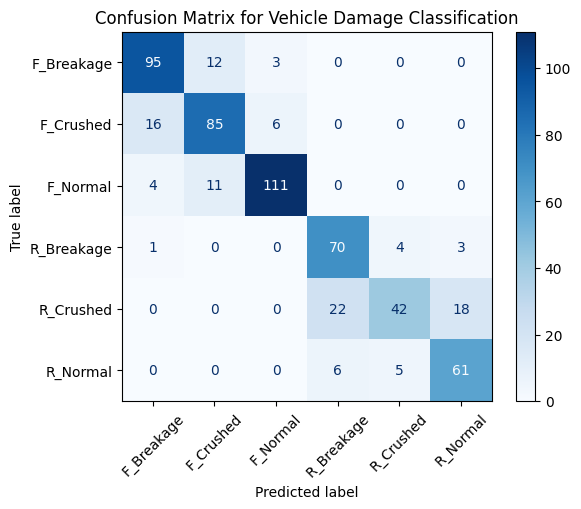

In [34]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from matplotlib import pyplot as plt

conf_matrix = confusion_matrix(labels, predictions, labels=np.arange(num_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix for Vehicle Damage Classification")
plt.show()

The confusion matrix shows that the model occasionally misclassifies slightly damaged cars as normal cars. This is likely because subtle dents and scratches can be visually difficult to distinguish, especially with a limited dataset.

To further improve performance, a larger and more diverse dataset could help the model learn more robust damage-related features. Additional data augmentation techniques may also improve generalization.

Other possible improvements include:
- Experimenting with grayscale image preprocessing
- Using ensemble learning approaches
- Trying different pretrained architectures
- Applying advanced computer vision models such as Vision Transformers (ViTs)

This project can be extended further by incorporating larger datasets, more sophisticated augmentation strategies, and modern deep learning architectures.

## Conclusion

This project explored multiple deep learning approaches for car damage classification, including custom CNN architectures, regularization techniques, transfer learning, and hyperparameter tuning.

Transfer learning models significantly outperformed baseline CNN models on the limited dataset. Among all approaches, the Optuna-tuned ResNet model achieved the best validation performance and generalization capability.

The final model was deployed using Streamlit and FastAPI for real-time image inference.

### Save the Model

In [35]:
torch.save(model.state_dict(), '../Model/saved_model.pth')